### Step 1: Setup
The helper stack is correctly handling mixed date formats and nested list parsing, which is confirmed later by zero date parse failures and stable list cardinality outputs.

In [1]:
from pathlib import Path
import ast
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display and plotting defaults for cleaner EDA output.
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("../datasets")


def parse_list_csv(value):
    if not isinstance(value, str) or not value.strip():
        return []
    return [token.strip() for token in value.split(",") if token and token.strip()]


def parse_name_dict_list(value):
    if not isinstance(value, str) or not value.strip():
        return []
    try:
        parsed = ast.literal_eval(value)
    except (SyntaxError, ValueError):
        return []
    if not isinstance(parsed, list):
        return []
    return [item.get("name", "").strip() for item in parsed if isinstance(item, dict) and item.get("name")]


def parse_mixed_dates(series):
    s = series.astype("string")
    parsed = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")

    # Try the known patterns in deterministic order and only fill missing slots.
    formats = ["%Y-%m-%d", "%m/%d/%Y", "%d-%m-%Y"]
    for fmt in formats:
        mask = parsed.isna() & s.notna()
        parsed.loc[mask] = pd.to_datetime(s.loc[mask], format=fmt, errors="coerce")

    # Final fallback for any rare pattern not captured above.
    mask = parsed.isna() & s.notna()
    parsed.loc[mask] = pd.to_datetime(s.loc[mask], errors="coerce")
    return parsed


def profile_missingness(df, name):
    total = len(df)
    summary = (
        df.isna()
        .sum()
        .rename("null_count")
        .to_frame()
        .assign(null_pct=lambda x: (x["null_count"] / total * 100).round(2))
        .sort_values(["null_count", "null_pct"], ascending=False)
    )
    summary.insert(0, "dataset", name)
    return summary


def id_quality(df, id_col, name):
    dup_mask = df[id_col].duplicated(keep=False)
    return {
        "dataset": name,
        "id_col": id_col,
        "rows": len(df),
        "unique_ids": int(df[id_col].nunique(dropna=True)),
        "null_ids": int(df[id_col].isna().sum()),
        "duplicate_rows_on_id": int(df.duplicated(subset=[id_col]).sum()),
        "is_unique": bool(df[id_col].is_unique),
        "sample_duplicate_ids": df.loc[dup_mask, id_col].astype(str).head(5).tolist(),
    }


def top_counts(series, top_n=10):
    return series.dropna().astype(str).str.strip().replace("", np.nan).dropna().value_counts().head(top_n)

### Step 2: Load Data
The ingestion baseline is 45,486 rows in `movies`, 45,466 in `movies_extended`, and 9,066 in `ratings`. This confirms near-full alignment between movie tables and a smaller ratings coverage subset.

In [2]:
movies = pd.read_csv(DATA_DIR / "movies_main.csv")
movies_extended = pd.read_csv(DATA_DIR / "movie_extended.csv")
ratings_raw = pd.read_json(DATA_DIR / "ratings.json")

ratings = (
    ratings_raw
    .assign(
        avg_rating=lambda d: d["ratings_summary"].map(lambda x: x.get("avg_rating") if isinstance(x, dict) else np.nan),
        total_ratings=lambda d: d["ratings_summary"].map(lambda x: x.get("total_ratings") if isinstance(x, dict) else np.nan),
        last_rated=lambda d: pd.to_datetime(d["last_rated"], unit="s", errors="coerce"),
    )
    .drop(columns=["ratings_summary"], errors="ignore")
)

movies = movies.assign(
    id=movies["id"].astype(str),
    budget_num=pd.to_numeric(movies["budget"], errors="coerce"),
    revenue_num=pd.to_numeric(movies["revenue"], errors="coerce"),
    release_date_parsed=parse_mixed_dates(movies["release_date"]),
)

movies_extended = movies_extended.assign(id=movies_extended["id"].astype(str))
ratings = ratings.assign(movie_id=ratings["movie_id"].astype(str))

display(pd.DataFrame({
    "dataset": ["movies", "movies_extended", "ratings"],
    "rows": [len(movies), len(movies_extended), len(ratings)],
    "columns": [movies.shape[1], movies_extended.shape[1], ratings.shape[1]],
}))

,dataset,rows,columns
0,movies,45486,8
1,movies_extended,45466,5
2,ratings,9066,4


### Step 3: Schema Check
Type structure is now consistent for profiling: IDs are string-based keys, dates are parsed to datetime, and financial fields are numeric. This enables reliable duplicate, join, and anomaly diagnostics.

In [3]:
schema_summary = pd.concat(
    [
        movies.dtypes.rename("movies"),
        movies_extended.dtypes.rename("movies_extended"),
        ratings.dtypes.rename("ratings"),
    ],
    axis=1,
)

display(schema_summary.fillna("-"))

,movies,movies_extended,ratings
id,object,object,-
title,object,-,-
release_date,object,-,-
budget,object,-,-
revenue,float64,-,-
budget_num,float64,-,-
revenue_num,float64,-,-
release_date_parsed,datetime64[ns],-,-
genres,-,object,-
production_companies,-,object,-


### Step 4: Numeric Profile
`movies` financial fields are highly zero-inflated with extreme right-skew, while ratings are tightly distributed (avg rating centered around ~3.29). This indicates financial outlier sensitivity but stable rating behavior.

In [4]:
numeric_profile = pd.concat(
    {
        "movies": movies.select_dtypes(include="number").describe().T,
        "ratings": ratings.select_dtypes(include="number").describe().T,
    },
    axis=0,
)

display(numeric_profile)

count          mean           std  min      25%  50%      75%           max
movies  revenue        45480.0  1.120587e+07  6.431874e+07  0.0  0.00000  0.0  0.00000  2.787965e+09
        budget_num     41049.0  3.787078e+06  1.649864e+07  0.0  0.00000  0.0  0.00000  3.800000e+08
        revenue_num    45480.0  1.120587e+07  6.431874e+07  0.0  0.00000  0.0  0.00000  2.787965e+09
ratings avg_rating      9066.0  3.292054e+00  8.819684e-01  0.5  2.84375  3.5  3.96625  5.000000e+00
        total_ratings   9066.0  1.103066e+01  2.405080e+01  1.0  1.00000  3.0  9.00000  3.410000e+02

### Step 5: Missingness Audit
The highest completeness risk is `production_companies` (~27.2% null) in `movies_extended` and `budget` (~9.75% null) in `movies`. Date nulls are low (~0.2%), and ratings fields are fully populated.

In [5]:
missing_summary = pd.concat(
    [
        profile_missingness(movies, "movies"),
        profile_missingness(movies_extended, "movies_extended"),
        profile_missingness(ratings, "ratings"),
    ]
)

# Show only fields that have any missing values.
display(missing_summary.query("null_count > 0"))

,dataset,null_count,null_pct
budget_num,movies,4437,9.75
budget,movies,4435,9.75
release_date,movies,90,0.20
release_date_parsed,movies,90,0.20
title,movies,6,0.01
revenue,movies,6,0.01
revenue_num,movies,6,0.01
production_companies,movies_extended,12365,27.20
genres,movies_extended,2442,5.37
spoken_languages,movies_extended,6,0.01


### Step 6: Parse Multi-Value Fields
Parsing produced usable list columns for genres, companies, countries, and languages with clean extraction from both comma-delimited and nested dict-like fields.

In [6]:
movies_extended = movies_extended.assign(
    genres_list=movies_extended["genres"].map(parse_list_csv),
    production_companies_list=movies_extended["production_companies"].map(parse_list_csv),
    country_names=movies_extended["production_countries"].map(parse_name_dict_list),
    language_names=movies_extended["spoken_languages"].map(parse_name_dict_list),
)

display(
    movies_extended[
        ["id", "genres_list", "production_companies_list", "country_names", "language_names"]
    ].head()
)

,id,genres_list,production_companies_list,country_names,language_names
0,862,"[Animation, Comedy, Family]",[Pixar Animation Studios],[United States of America],[English]
1,8844,"[Adventure, Fantasy, Family]","[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],"[English, Français]"
2,15602,"[Romance, Comedy]","[Warner Bros., Lancaster Gate]",[United States of America],[English]
3,31357,"[Comedy, Drama, Romance]",[Twentieth Century Fox Film Corporation],[United States of America],[English]
4,11862,[Comedy],"[Sandollar Productions, Touchstone Pictures]",[United States of America],[English]


### Step 7: Multi-Value Quality Summary
Average items per movie are moderate (`genres` ~2.00, `companies` ~1.52), but long tails exist (max companies = 26), confirming many-to-many relationships are material for modeling.

In [7]:
multivalue_quality = pd.DataFrame(
    {
        "field": ["genres", "production_companies", "production_countries", "spoken_languages"],
        "avg_items_per_movie": [
            movies_extended["genres_list"].str.len().mean(),
            movies_extended["production_companies_list"].str.len().mean(),
            movies_extended["country_names"].str.len().mean(),
            movies_extended["language_names"].str.len().mean(),
        ],
        "max_items_per_movie": [
            movies_extended["genres_list"].str.len().max(),
            movies_extended["production_companies_list"].str.len().max(),
            movies_extended["country_names"].str.len().max(),
            movies_extended["language_names"].str.len().max(),
        ],
    }
)

display(multivalue_quality)

,field,avg_items_per_movie,max_items_per_movie
0,genres,2.003827,8
1,production_companies,1.515352,26
2,production_countries,1.086702,25
3,spoken_languages,1.161351,18


### Step 8: Top Category Frequencies
Category concentration is strong: Drama and Comedy dominate genres, the United States dominates production country, and English dominates language. These skews should be considered in comparative analysis.

In [8]:
genre_counts = top_counts(movies_extended.explode("genres_list")["genres_list"], top_n=15)
country_counts = top_counts(movies_extended.explode("country_names")["country_names"], top_n=15)
language_counts = top_counts(movies_extended.explode("language_names")["language_names"], top_n=15)

for label, counts in [
    ("genres", genre_counts),
    ("countries", country_counts),
    ("languages", language_counts),
]:
    print(f"Top {len(counts)} {label}")
    display(counts.rename("movie_count").to_frame())

Top 15 genres


,movie_count
genres_list,
Drama,20265
Comedy,13182
Thriller,7624
Romance,6735
Action,6596
Horror,4673
Crime,4307
Documentary,3932
Adventure,3496


Top 15 countries


,movie_count
country_names,
United States of America,21153
United Kingdom,4094
France,3938
Germany,2253
Italy,2168
Canada,1764
Japan,1648
Spain,964
Russia,912


Top 15 languages


,movie_count
language_names,
English,28745
Français,4196
Deutsch,2625
Español,2413
Italiano,2367
日本語,1758
Pусский,1563
普通话,790
हिन्दी,707


### Step 9: Ratings Validation
Ratings quality is clean in this dataset: null and invalid counts are zero for `avg_rating`, `total_ratings`, and `last_rated`, so ratings can be used directly for downstream metrics.

In [9]:
ratings_quality = (
    ratings.assign(
        avg_rating=pd.to_numeric(ratings["avg_rating"], errors="coerce"),
        total_ratings=pd.to_numeric(ratings["total_ratings"], errors="coerce"),
    )
    .assign(
        invalid_avg_rating=lambda d: ~d["avg_rating"].between(0, 10, inclusive="both"),
        invalid_total_ratings=lambda d: d["total_ratings"].lt(0),
    )
)

summary = {
    "rows": len(ratings_quality),
    "null_avg_rating": int(ratings_quality["avg_rating"].isna().sum()),
    "null_total_ratings": int(ratings_quality["total_ratings"].isna().sum()),
    "invalid_avg_rating": int(ratings_quality["invalid_avg_rating"].sum()),
    "invalid_total_ratings": int(ratings_quality["invalid_total_ratings"].sum()),
    "null_last_rated": int(ratings_quality["last_rated"].isna().sum()),
}

print("Ratings quality summary")
display(pd.Series(summary).rename("count").to_frame())
display(ratings_quality.head())

Ratings quality summary


,count
rows,9066
null_avg_rating,0
null_total_ratings,0
invalid_avg_rating,0
invalid_total_ratings,0
null_last_rated,0


,movie_id,last_rated,avg_rating,total_ratings,invalid_avg_rating,invalid_total_ratings
0,1,2016-10-06 19:55:11,3.872470,247,False,False
1,2,2016-08-01 17:42:33,3.401869,107,False,False
2,3,2016-08-16 22:07:21,3.161017,59,False,False
3,4,2004-07-27 06:14:12,2.384615,13,False,False
4,5,2016-08-16 22:15:47,3.267857,56,False,False


## Visualizations

### Step 10: Categorical Visuals
Visual distribution confirms the same concentration seen in tables, with steep drop-offs after the top categories. This supports using top-N segmentation instead of uniform category treatment.

/home/steph/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24191 (\N{CJK UNIFIED IDEOGRAPH-5E7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/steph/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24030 (\N{CJK UNIFIED IDEOGRAPH-5DDE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/steph/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35805 (\N{CJK UNIFIED IDEOGRAPH-8BDD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/steph/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24291 (\N{CJK UNIFIED IDEOGRAPH-5EE3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/steph/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35441 (\N{CJK UNIFIED IDE

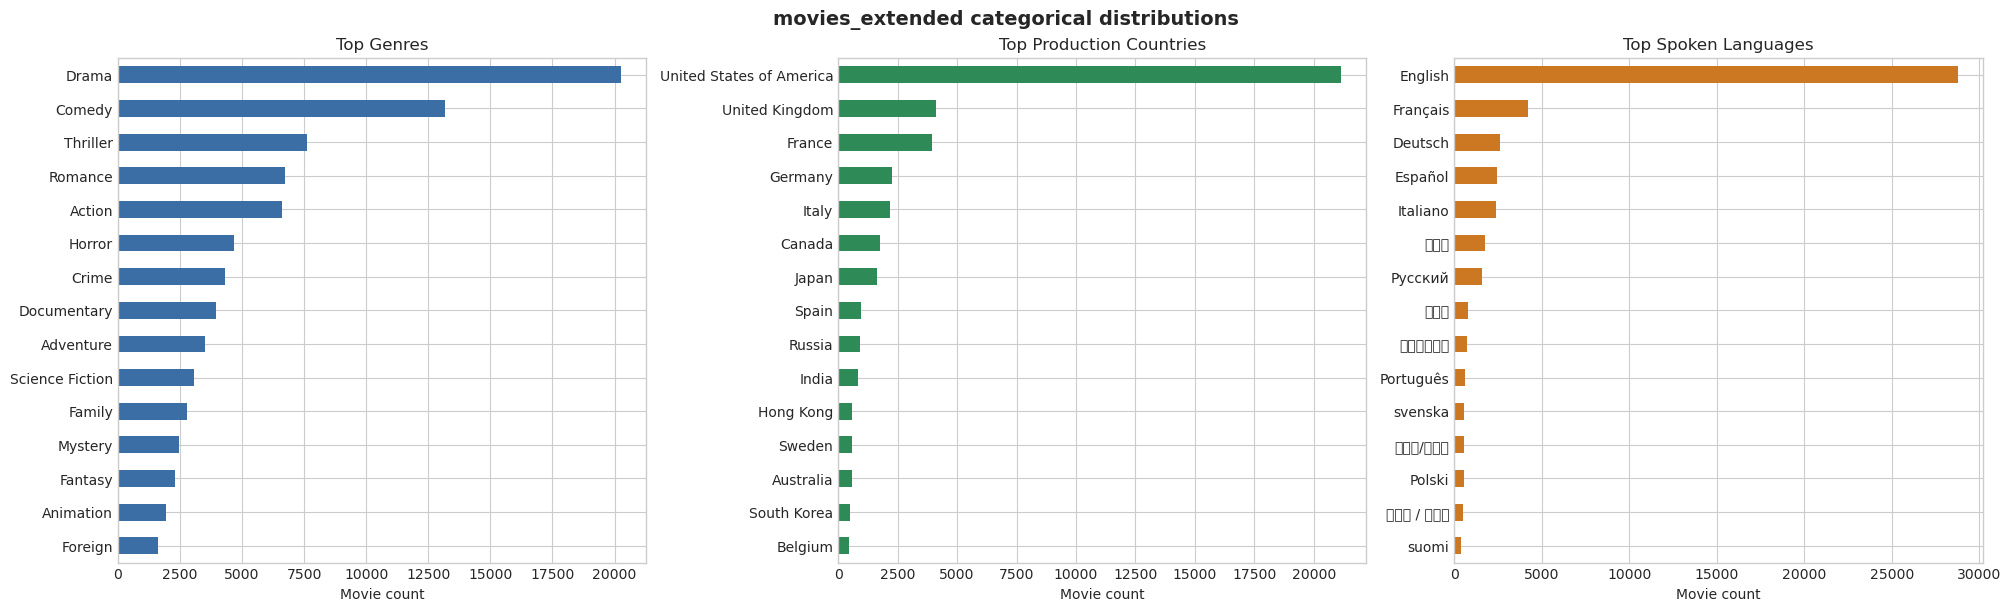

In [10]:
bar_charts = [
    (genre_counts, "Top Genres", "#3A6EA5"),
    (country_counts, "Top Production Countries", "#2E8B57"),
    (language_counts, "Top Spoken Languages", "#CC7722"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle("movies_extended categorical distributions", fontsize=14, fontweight="bold")

for ax, (data, title, color) in zip(axes, bar_charts):
    data.sort_values().plot(kind="barh", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("Movie count")
    ax.set_ylabel("")

plt.show()

### Step 11: Ratings Visuals
Ratings cluster around the low-to-mid 3 range, and the most-rated titles are concentrated in a small head group. This indicates stable central tendency with popularity concentration.

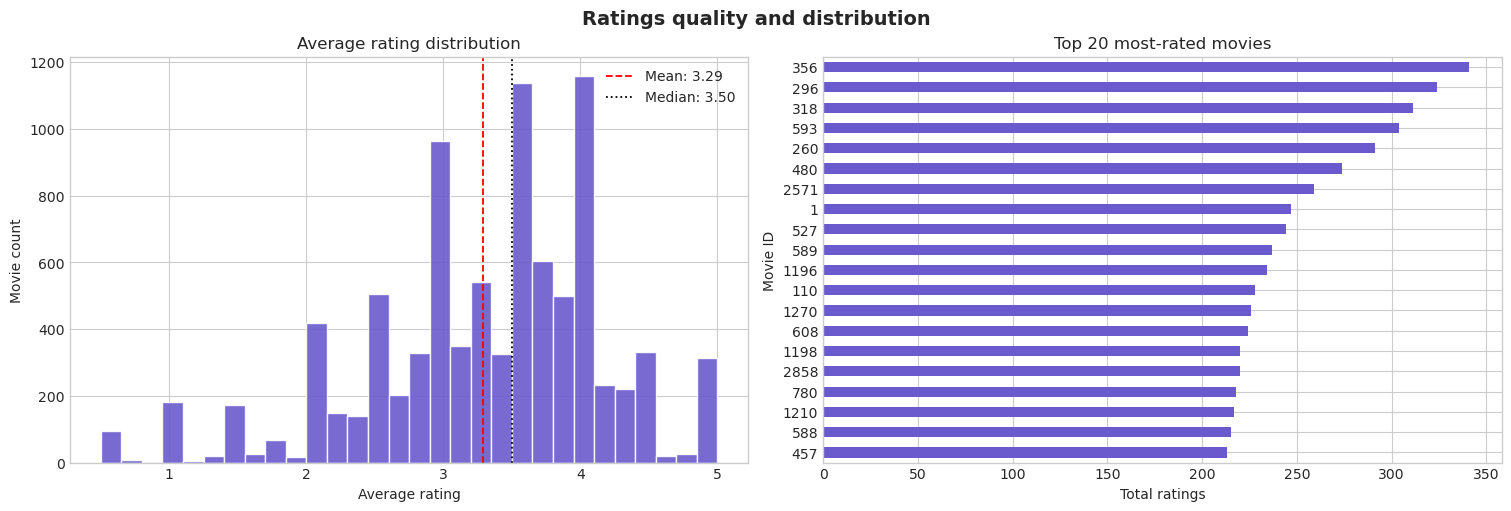

In [11]:
ratings_plot = ratings_quality.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
fig.suptitle("Ratings quality and distribution", fontsize=14, fontweight="bold")

valid_avg = ratings_plot["avg_rating"].dropna()
axes[0].hist(valid_avg, bins=30, color="#6A5ACD", edgecolor="white", alpha=0.9)
axes[0].axvline(valid_avg.mean(), color="red", linestyle="--", linewidth=1.3, label=f"Mean: {valid_avg.mean():.2f}")
axes[0].axvline(valid_avg.median(), color="black", linestyle=":", linewidth=1.3, label=f"Median: {valid_avg.median():.2f}")
axes[0].set_title("Average rating distribution")
axes[0].set_xlabel("Average rating")
axes[0].set_ylabel("Movie count")
axes[0].legend()

(
    ratings_plot.sort_values("total_ratings", ascending=False)
    .head(20)
    .set_index("movie_id")["total_ratings"]
    .sort_values()
    .plot(kind="barh", ax=axes[1], color="#6A5ACD")
)
axes[1].set_title("Top 20 most-rated movies")
axes[1].set_xlabel("Total ratings")
axes[1].set_ylabel("Movie ID")

plt.show()

### Step 12: Financial Visuals
The valid financial subset (4,339 movies) shows heavy right-skew and wide ROI dispersion, including extreme upside tails. Median ROI (~1.05) suggests typical positive return in this filtered subset.

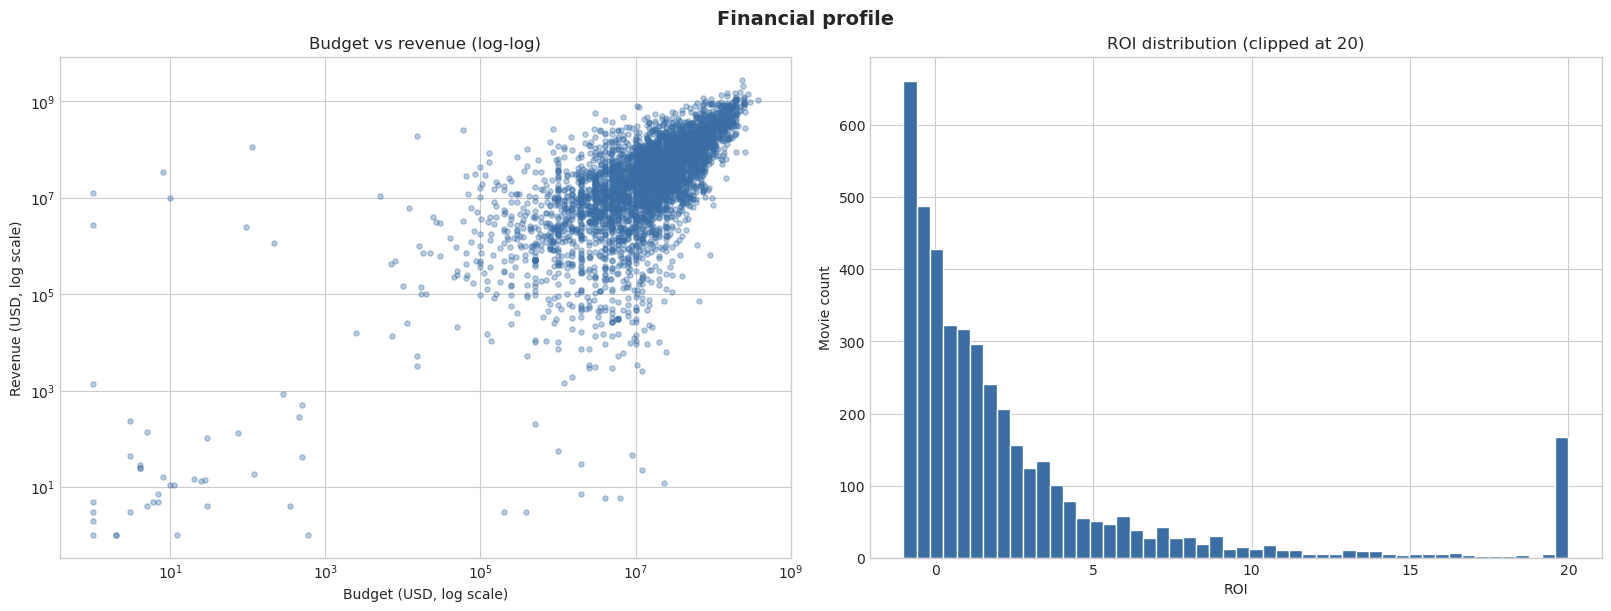

Movies with valid financials: 4,339
Median budget: $17,000,000
Median revenue: $29,712,172
Median ROI: 1.05


In [12]:
movies_plot = movies.query("budget_num > 0 and revenue_num > 0").copy()
movies_plot["roi"] = (movies_plot["revenue_num"] - movies_plot["budget_num"]) / movies_plot["budget_num"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle("Financial profile", fontsize=14, fontweight="bold")

axes[0].scatter(
    movies_plot["budget_num"],
    movies_plot["revenue_num"],
    alpha=0.35,
    s=14,
    color="#3A6EA5",
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Budget vs revenue (log-log)")
axes[0].set_xlabel("Budget (USD, log scale)")
axes[0].set_ylabel("Revenue (USD, log scale)")

axes[1].hist(movies_plot["roi"].clip(-1, 20), bins=50, color="#3A6EA5", edgecolor="white")
axes[1].set_title("ROI distribution (clipped at 20)")
axes[1].set_xlabel("ROI")
axes[1].set_ylabel("Movie count")

plt.show()

print(f"Movies with valid financials: {len(movies_plot):,}")
print(f"Median budget: ${movies_plot['budget_num'].median():,.0f}")
print(f"Median revenue: ${movies_plot['revenue_num'].median():,.0f}")
print(f"Median ROI: {movies_plot['roi'].median():.2f}")

---
## Phase 1: Structural Profiling — The "Skeleton"

### Step 13: Structural Profiling Checks
ID quality issues are concentrated in movie tables (`movies` duplicate IDs = 50, `movies_extended` = 30), while ratings IDs are unique. Referential integrity gap is mainly from ratings (6,236 IDs not in `movies`).

In [13]:
print("=== Structural Profiling ===")

id_checks = pd.DataFrame(
    [
        id_quality(movies, "id", "movies"),
        id_quality(movies_extended, "id", "movies_extended"),
        id_quality(ratings, "movie_id", "ratings"),
    ]
)

display(id_checks)

main_ids = set(movies["id"])
extended_ids = set(movies_extended["id"])
ratings_ids = set(ratings["movie_id"])

integrity_report = pd.DataFrame(
    [
        {
            "check": "extended_not_in_main",
            "count": len(extended_ids - main_ids),
            "sample": sorted(list(extended_ids - main_ids))[:5],
        },
        {
            "check": "ratings_not_in_main",
            "count": len(ratings_ids - main_ids),
            "sample": sorted(list(ratings_ids - main_ids))[:5],
        },
        {
            "check": "main_not_in_extended",
            "count": len(main_ids - extended_ids),
            "sample": sorted(list(main_ids - extended_ids))[:5],
        },
    ]
)

display(integrity_report)

with open(DATA_DIR / "ratings.json", "r", encoding="utf-8") as file:
    raw = json.load(file)

print(f"ratings.json top-level type: {type(raw).__name__}")
print(f"ratings.json records: {len(raw):,}")
display(pd.DataFrame(raw[:3]))

=== Structural Profiling ===


,dataset,id_col,rows,unique_ids,null_ids,duplicate_rows_on_id,is_unique,sample_duplicate_ids
0,movies,id,45486,45436,0,50,False,"[48787, 105045, 132641, 22649, 105045]"
1,movies_extended,id,45466,45436,0,30,False,"[105045, 132641, 22649, 105045, 84198]"
2,ratings,movie_id,9066,9066,0,0,True,[]


,check,count,sample
0,extended_not_in_main,0,[]
1,ratings_not_in_main,6236,"[1, 10, 100034, 100083, 100106]"
2,main_not_in_extended,0,[]


ratings.json top-level type: list
ratings.json records: 9,066


,movie_id,ratings_summary,last_rated
0,1,"{'avg_rating': 3.8724696356275303, 'total_rati...",1475783711
1,2,"{'avg_rating': 3.4018691588785046, 'total_rati...",1470073353
2,3,"{'avg_rating': 3.1610169491525424, 'total_rati...",1471385241


---
## Phase 2: Data Quality & Anomalies — The "Rubric" Problems

### Step 14: Data Quality Anomaly Checks
Core anomalies are duplicate movie IDs, zero-heavy financial columns (`budget_zeros` 33,887; `revenue_zeros` 38,068), and 31,534 rows where both are zero. Date parsing is no longer an issue after mixed-format handling (failures = 0).

In [14]:
print("=== Data Quality Audit ===")

# Duplicate diagnostics
exact_dups = int(movies.duplicated().sum())
id_dups = int(movies.duplicated(subset=["id"]).sum())

# Date format diagnostics
raw_dates = movies["release_date"].dropna().astype(str)
parsed_dates = parse_mixed_dates(raw_dates)

date_patterns = {
    "YYYY-MM-DD": r"^\d{4}-\d{2}-\d{2}$",
    "MM/DD/YYYY": r"^\d{2}/\d{2}/\d{4}$",
    "DD-MM-YYYY": r"^\d{2}-\d{2}-\d{4}$",
}

pattern_counts = {name: int(raw_dates.str.match(pattern).sum()) for name, pattern in date_patterns.items()}

# Numeric quality diagnostics
budget = movies["budget_num"]
revenue = movies["revenue_num"]

quality_summary = pd.DataFrame(
    [
        {"metric": "exact_duplicate_rows", "value": exact_dups},
        {"metric": "duplicate_movie_ids", "value": id_dups},
        {"metric": "release_date_total_non_null", "value": int(raw_dates.shape[0])},
        {"metric": "release_date_parse_failures", "value": int(parsed_dates.isna().sum())},
        {"metric": "budget_nulls", "value": int(budget.isna().sum())},
        {"metric": "budget_zeros", "value": int((budget == 0).sum())},
        {"metric": "budget_negatives", "value": int((budget < 0).sum())},
        {"metric": "revenue_nulls", "value": int(revenue.isna().sum())},
        {"metric": "revenue_zeros", "value": int((revenue == 0).sum())},
        {"metric": "revenue_negatives", "value": int((revenue < 0).sum())},
        {
            "metric": "both_budget_and_revenue_zero",
            "value": int(((budget == 0) & (revenue == 0)).sum()),
        },
    ]
)

display(quality_summary)
print("Date pattern counts:")
display(pd.Series(pattern_counts, name="count").to_frame())

if id_dups > 0:
    display(movies[movies.duplicated(subset=["id"], keep=False)].head(10))

failed_date_samples = raw_dates[parsed_dates.isna()].head(10)
if not failed_date_samples.empty:
    print("Sample failed release_date values:")
    display(failed_date_samples.to_frame(name="release_date"))

=== Data Quality Audit ===


,metric,value
0,exact_duplicate_rows,6
1,duplicate_movie_ids,50
2,release_date_total_non_null,45396
3,release_date_parse_failures,0
4,budget_nulls,4437
5,budget_zeros,33887
6,budget_negatives,0
7,revenue_nulls,6
8,revenue_zeros,38068
9,revenue_negatives,0


Date pattern counts:


,count
YYYY-MM-DD,15194
MM/DD/YYYY,15067
DD-MM-YYYY,15135


,id,title,release_date,budget,revenue,budget_num,revenue_num,release_date_parsed
180,48787,Mute Witness,1995-09-28,2,1.0,2.0,1.0,1995-09-28
676,105045,The Promise,16-02-1995,0,0.0,0.0,0.0,1995-02-16
838,132641,Wife,29-04-1953,0,0.0,0.0,0.0,1953-04-29
949,22649,A Farewell to Arms,12/08/1932,4,25.0,4.0,25.0,1932-12-08
1465,105045,The Promise,02/16/1995,0,0.0,0.0,0.0,1995-02-16
2564,84198,A Place at the Table,2012-03-22,0,0.0,0.0,0.0,2012-03-22
2655,11353,Bowfinger,1999-08-12,55000000,0.0,55000000.0,0.0,1999-08-12
3434,1443,The Virgin Suicides,21-04-1999,6000000,10409377.0,6000000.0,10409377.0,1999-04-21
3888,37716,Mr Accident,2000-03-24,0,0.0,0.0,0.0,2000-03-24
3982,71881,Five Corners,09/11/1987,0,0.0,0.0,0.0,1987-09-11


---
## Phase 3: Cardinality & Multi-Value Profiling — For the ERD

### Step 15: Cardinality and Token Quality Checks
Dimensional scale is substantial (`dim_company` ~23,005 unique) with cleaner bounds for genres (32) and countries (158). Token spacing inconsistency appears mainly in production companies, not genres.

In [15]:
print("=== Cardinality and Multi-Value Quality ===")

delimiter_quality = pd.DataFrame(
    [
        {
            "field": "genres",
            "contains_comma_space_pattern": bool(movies_extended["genres"].fillna("").str.contains(r",\s|\s,").any()),
            "max_items": int(movies_extended["genres_list"].str.len().max()),
            "mean_items": float(movies_extended["genres_list"].str.len().mean()),
        },
        {
            "field": "production_companies",
            "contains_comma_space_pattern": bool(movies_extended["production_companies"].fillna("").str.contains(r",\s|\s,").any()),
            "max_items": int(movies_extended["production_companies_list"].str.len().max()),
            "mean_items": float(movies_extended["production_companies_list"].str.len().mean()),
        },
    ]
)

display(delimiter_quality)

genre_lengths = movies_extended["genres_list"].str.len()
display(genre_lengths.value_counts().sort_index().rename("movie_count").to_frame())

unique_genres = movies_extended["genres_list"].explode().dropna().str.strip()
unique_companies = movies_extended["production_companies_list"].explode().dropna().str.strip()
unique_countries = movies_extended["country_names"].explode().dropna().str.strip()

dimension_sizes = pd.DataFrame(
    [
        {"dimension": "dim_genre", "unique_count": int(unique_genres.nunique())},
        {"dimension": "dim_company", "unique_count": int(unique_companies.nunique())},
        {"dimension": "dim_country", "unique_count": int(unique_countries.nunique())},
    ]
)

display(dimension_sizes)

print("Top examples")
print(f"Genres: {unique_genres.value_counts().head(5).index.tolist()}")
print(f"Companies: {unique_companies.value_counts().head(5).index.tolist()}")
print(f"Countries: {unique_countries.value_counts().head(5).index.tolist()}")

=== Cardinality and Multi-Value Quality ===


,field,contains_comma_space_pattern,max_items,mean_items
0,genres,False,8,2.003827
1,production_companies,True,26,1.515352


,movie_count
genres_list,
0,2442
1,14559
2,14480
3,9586
4,3380
5,835
6,157
7,24
8,3


,dimension,unique_count
0,dim_genre,32
1,dim_company,23005
2,dim_country,158


Top examples
Genres: ['Drama', 'Comedy', 'Thriller', 'Romance', 'Action']
Companies: ['Warner Bros.', 'Metro-Goldwyn-Mayer (MGM)', 'Paramount Pictures', 'Universal Pictures', 'Twentieth Century Fox Film Corporation']
Countries: ['United States of America', 'United Kingdom', 'France', 'Germany', 'Italy']


---
## Phase 4: Financial & Statistical Profiling — The "Business" Logic

### Step 16: Financial Statistical Checks
Financial ranges are broad, with 47 likely low-budget data artifacts (<$10k). Budget tiers are fairly balanced (Low 1,447; Mid 1,511; High 1,381), and budget-revenue correlation is strong (Pearson r = 0.734).

=== Financial and Statistical Profiling ===


,field,min,p50,p90,max
0,budget_num,1.0,17000000.0,80000000.0,3.800000e+08
1,revenue_num,1.0,29712172.0,237131007.0,2.787965e+09


Budget < $10k rows: 47


,id,title,budget_num,revenue_num
180,48787,Mute Witness,2.0,1.0
185,11980,The Prophecy,8.0,16.0
274,17402,Miami Rhapsody,6.0,5.0
922,220,East of Eden,1.0,5.0
949,22649,A Farewell to Arms,4.0,25.0
1150,10174,Madonna: Truth or Dare,4.0,29.0
2308,8856,"The Karate Kid, Part II",113.0,115103979.0
2374,47139,"Blood, Guts, Bullets and Octane",7300.0,13674.0
3062,10397,Angela's Ashes,25.0,13.0
3865,16340,Rugrats in Paris: The Movie,30.0,103.0


,movie_count
budget_tier,
Low,1447
Mid,1511
High,1381


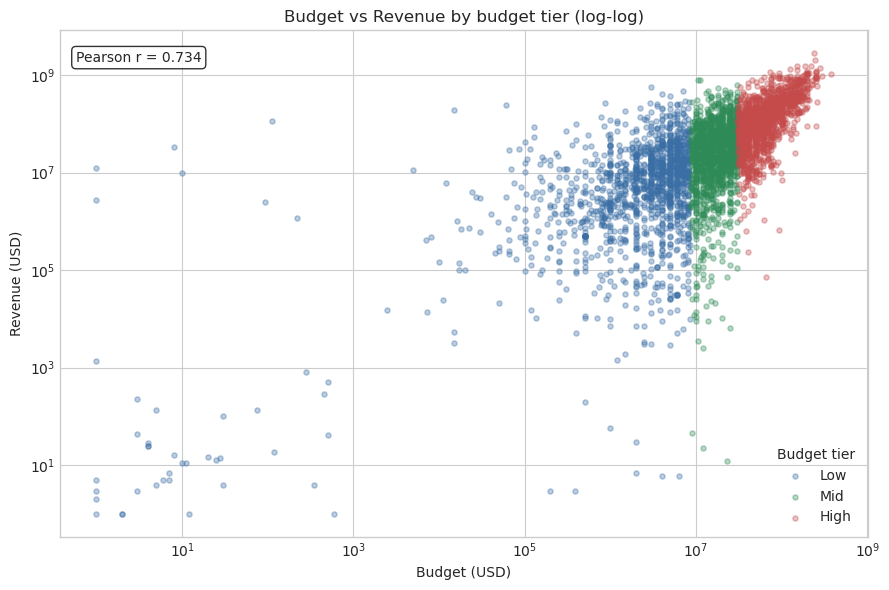

Pearson correlation (budget vs revenue): 0.734


In [16]:
fin_valid = movies.query("budget_num > 0 and revenue_num > 0").copy()

print("=== Financial and Statistical Profiling ===")

range_report = pd.DataFrame(
    [
        {
            "field": "budget_num",
            "min": fin_valid["budget_num"].min(),
            "p50": fin_valid["budget_num"].median(),
            "p90": fin_valid["budget_num"].quantile(0.9),
            "max": fin_valid["budget_num"].max(),
        },
        {
            "field": "revenue_num",
            "min": fin_valid["revenue_num"].min(),
            "p50": fin_valid["revenue_num"].median(),
            "p90": fin_valid["revenue_num"].quantile(0.9),
            "max": fin_valid["revenue_num"].max(),
        },
    ]
)
display(range_report)

low_budget_outliers = fin_valid[fin_valid["budget_num"] < 10_000][["id", "title", "budget_num", "revenue_num"]]
print(f"Budget < $10k rows: {len(low_budget_outliers):,}")
if not low_budget_outliers.empty:
    display(low_budget_outliers.head(10))

p33, p66 = fin_valid["budget_num"].quantile([0.33, 0.66])
fin_valid["budget_tier"] = pd.cut(
    fin_valid["budget_num"],
    bins=[0, p33, p66, np.inf],
    labels=["Low", "Mid", "High"],
)

display(fin_valid["budget_tier"].value_counts().sort_index().rename("movie_count").to_frame())

fig, ax = plt.subplots(figsize=(9, 6))
colors = {"Low": "#3A6EA5", "Mid": "#2E8B57", "High": "#C54B4B"}

for tier, group in fin_valid.groupby("budget_tier", observed=True):
    ax.scatter(
        group["budget_num"],
        group["revenue_num"],
        alpha=0.35,
        s=14,
        label=tier,
        color=colors[str(tier)],
    )

corr = fin_valid[["budget_num", "revenue_num"]].corr().iloc[0, 1]
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Budget vs Revenue by budget tier (log-log)")
ax.set_xlabel("Budget (USD)")
ax.set_ylabel("Revenue (USD)")
ax.legend(title="Budget tier")
ax.text(
    0.02,
    0.96,
    f"Pearson r = {corr:.3f}",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
)

plt.tight_layout()
plt.show()

print(f"Pearson correlation (budget vs revenue): {corr:.3f}")